## COVID Drivers: Modeling

This notebook models POST_COVID ~ NO_CLEARANCE

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Random Forest Classifier](#rfc)</BR>
* [Random Forest Classifier with GridSearchCV](#rf-gs)
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [XGBoost](#xgb)</BR>
* [XGBoost with GridSearchCV](#xgb-gs)</BR>
* [Review Models](#review)


Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [2]:
# Import project specific utilities
from utils.functions import *

In [3]:
path_in = 'data/ready/ready_data.csv'

### <a id='read'>Read the data</a>

In [4]:
df_init = pd.read_csv(path_in, low_memory=False)

In [5]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [6]:
df_init['NO_CLEARANCE'].sum()/df_init.shape[0]

np.float64(0.0681865844281044)

In [7]:
df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')]['NO_CLEARANCE'].sum()/df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].shape[0]

np.float64(0.07250149068883008)

In [8]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [9]:
model_metrics = []

In [10]:
df.columns.tolist()

['POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx']

### <a id='prep'>Preprocessing</a>

In [11]:
X = df.loc[:,['POST_COVID']].copy()

In [12]:
y = df['NO_CLEARANCE']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
categorical_cols = ['URBAN_RURALx']

In [15]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ])

### <a id='rfc'>Random Forest Classifier</a>

In [17]:
rf_pipeline = Pipeline(steps=[
    #('preprocessor', preprocessor),
    ('random_forest', RandomForestClassifier(random_state=42, class_weight='balanced_subsample'))
])

In [18]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each spl

In [19]:
y_pred = rf_pipeline.predict(X_test)


In [20]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 74.47%


In [21]:
conf_matrix = confusion_matrix(y_test, y_pred)

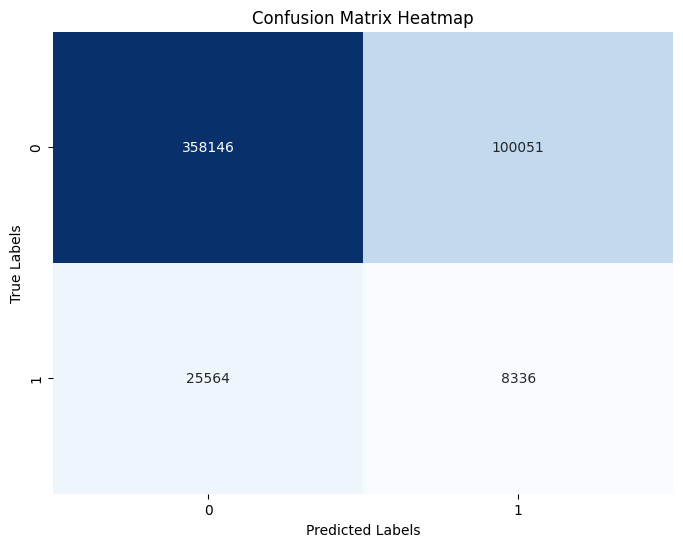

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [23]:
rf_pipeline.named_steps['random_forest'].feature_importances_

array([1.])

In [24]:

"""importances = rf_pipeline.named_steps['random_forest'].feature_importances_

plt.barh(df['POST_COVID'], importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()"""


"importances = rf_pipeline.named_steps['random_forest'].feature_importances_\n\nplt.barh(df['POST_COVID'], importances)\nplt.xlabel('Feature Importance')\nplt.title('Feature Importance in Random Forest Classifier')\nplt.show()"

In [25]:
# Predicted probabilities for the class 1
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [26]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [27]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [28]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [29]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [30]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier'

In [31]:
aggdrv_rf = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [32]:
aggdrv_rf['RandomForestClassifier'] = [round(x, 4) for x in aggdrv_rf['RandomForestClassifier']]

In [33]:
aggdrv_rf

,Measure,RandomForestClassifier
0,Accuracy,0.7447
1,Precision,0.0769
2,Recall,0.2459
3,F1 Score,0.1172
4,ROC AUC,0.5138


In [34]:
model_metrics.append(aggdrv_rf)

In [35]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85    458197
           1       0.08      0.25      0.12     33900

    accuracy                           0.74    492097
   macro avg       0.51      0.51      0.48    492097
weighted avg       0.87      0.74      0.80    492097



### <a id='rf-gs'>Random Forest Classifier with GridSearchCV</a>

In [60]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5, 8]
}

In [61]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced_subsample'),
                                 param_grid=param_grid,
                                 cv=5,
                                 scoring='f1',
                                 return_train_score=True,
                                 refit=True)

In [62]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [63]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

In [64]:
y_pred = grid_search.predict(X_test)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 74.47%


In [66]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [67]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [68]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [69]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [70]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [71]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier_GridSearchCV'

In [72]:
aggdrv_rfcv = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [73]:
aggdrv_rfcv['RandomForestClassifier_GridSearchCV'] = [round(x, 4) for x in aggdrv_rfcv['RandomForestClassifier_GridSearchCV']]

In [74]:
aggdrv_rfcv

,Measure,RandomForestClassifier_GridSearchCV
0,Accuracy,0.7447
1,Precision,0.0769
2,Recall,0.2459
3,F1 Score,0.1172
4,ROC AUC,0.5138


In [75]:
model_metrics.append(aggdrv_rfcv)

In [76]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85    458197
           1       0.08      0.25      0.12     33900

    accuracy                           0.74    492097
   macro avg       0.51      0.51      0.48    492097
weighted avg       0.87      0.74      0.80    492097



### <a id='lgr-cv'>Logistic Regression with Cross Validation</a>

In [ ]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(class_weight='balanced', random_state=42, cv=10, solver='saga', l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9], use_legacy_attributes=False, max_iter=5000))
])

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# set cv=skf

In [30]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(class_weight='balanced', random_state=42, cv=skf, solver='saga', l1_ratios=[0.9], use_legacy_attributes=False, max_iter=5000))
])

In [ ]:
lgr_pipeline.fit(X_train, y_train)

In [ ]:
y_pred = lgr_pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [ ]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [ ]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [ ]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [ ]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [ ]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [ ]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [ ]:
aggdrv_lgr

In [ ]:
model_metrics.append(aggdrv_lgr)

In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### <a id='xgb'>XGBoost</a>

In [42]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(13.703500358551452)

In [43]:
clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight
)

In [44]:
clf.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [45]:
y_pred = clf.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 74.47%


In [47]:
# Predicted probabilities for the class 1
y_pred_proba = clf.predict_proba(X_test)[:, 1]

In [48]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [49]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [50]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [51]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [52]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'XGBoost'

In [53]:
aggdrv_xgb = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [54]:
aggdrv_xgb['XGBoost'] = [round(x, 4) for x in aggdrv_xgb['XGBoost']]

In [55]:
aggdrv_xgb

,Measure,XGBoost
0,Accuracy,0.7447
1,Precision,0.0769
2,Recall,0.2459
3,F1 Score,0.1172
4,ROC AUC,0.5138


In [56]:
model_metrics.append(aggdrv_xgb)

### <a id='review'>Review Models</a>

In [77]:
merged_metrics = reduce(lambda left, right: pd.merge(left, right, on='Measure', how='inner'), model_metrics)

In [78]:
merged_metrics

,Measure,RandomForestClassifier,XGBoost,RandomForestClassifier_GridSearchCV
0,Accuracy,0.7447,0.7447,0.7447
1,Precision,0.0769,0.0769,0.0769
2,Recall,0.2459,0.2459,0.2459
3,F1 Score,0.1172,0.1172,0.1172
4,ROC AUC,0.5138,0.5138,0.5138


In [79]:
merged_metrics.to_csv('data/model_metrics/metrics_10_models_1x.csv', index=False)